### 🥔 Potato Leaf Disease Classification

This notebook focuses on training a lightweight deep learning model, specifically a modified **LeNet architecture**, for multiclass **potato leaf disease classification**. The objective is to accurately identify multiple potato leaf conditions, including healthy and various disease classes, while maintaining low computational requirements.

The model is trained and evaluated using a subset of the Kaggle *Plant Diseases Training Dataset*:
https://www.kaggle.com/datasets/nirmalsankalana/plant-diseases-training-dataset

The workflow includes:
- Data preprocessing and augmentation  
- Model design using a modified LeNet architecture  
- Training and validation  
- Performance evaluation  
- Explainability using **Grad-CAM (Gradient-weighted Class Activation Mapping)**  


### 1. Problem Definition & Dataset Selection

The problem addressed in this study is the automated classification of **potato leaf diseases** using image-based deep learning techniques. The goal is to distinguish between **healthy leaves** and multiple disease conditions affecting potato crops.

Plant diseases significantly impact agricultural productivity by reducing crop yield and quality. Early detection and accurate classification are essential for effective disease management, minimizing economic losses, and reducing excessive pesticide usage. In potato farming, timely identification of diseases is crucial for improving crop yield and ensuring food security.

Manual disease diagnosis is often:
- Time-consuming  
- Subjective  
- Dependent on expert knowledge  

This motivates the need for **automated, reliable, and scalable solutions**.


### 2. Dataset Description

A publicly available dataset from Kaggle, the *Plant Diseases Training Dataset*, is used in this study. From this dataset, the following **potato leaf categories** are selected:

- `Potato___bacterial_wilt` (569 images)  
- `Potato___early_blight` (2628 images)  
- `Potato___healthy` (2275 images)  
- `Potato___late_blight` (2087 images)  
- `Potato___leafroll_virus` (527 images)  
- `Potato___mosaic_virus` (666 images)  
- `Potato___nematode` (68 images)  
- `Potato___pests` (611 images)  
- `Potato___phytophthora` (347 images)  

This defines a **multiclass classification task** with **9 classes**.

Using this focused subset:
- Reduces irrelevant data from other plant species  
- Improves computational efficiency  
- Enhances model interpretability  
- Retains sufficient diversity for effective learning  


### 3. Model Selection: Modified LeNet

This study utilizes a **modified LeNet convolutional neural network (CNN)** architecture due to its simplicity and efficiency.

Key advantages of LeNet:
- Lightweight and computationally efficient  
- Suitable for small to medium-sized datasets  
- Effective in learning spatial hierarchies in images  
- Faster training compared to deeper architectures  

LeNet provides a strong balance between **performance and resource usage**, making it suitable for deployment in resource-constrained environments.


### 4. Deep Learning for Image-Based Disease Detection

Convolutional Neural Networks (CNNs) are well-suited for image classification tasks because they:
- Automatically extract hierarchical features  
- Capture patterns such as texture, color, and shape  
- Learn discriminative representations directly from raw images  

This enables accurate identification of disease characteristics without manual feature engineering.


### 5. Explainable AI with Grad-CAM

To improve model transparency and interpretability, this study incorporates **Grad-CAM (Gradient-weighted Class Activation Mapping)**.

Grad-CAM allows visualization of:
- Which regions of the leaf image influence model predictions  
- Whether the model focuses on disease-affected areas  

Benefits of using Grad-CAM:
- Enhances trust in model predictions  
- Provides visual explanations for classification decisions  
- Helps validate that the model is learning meaningful features  
- Supports debugging and model improvement  

This is particularly important in agricultural and real-world applications, where understanding *why* a prediction is made is as critical as the prediction itself.


### 6. Summary

This study presents a lightweight and interpretable approach to potato leaf disease classification by:
- Using a **modified LeNet CNN** for efficient image classification  
- Handling **9 potato leaf classes**, including both healthy and diseased conditions  
- Applying **Grad-CAM** for explainable AI  

The approach aims to deliver an effective, scalable, and transparent solution for automated plant disease detection in potato crops.

In the following code cell we are going to import all the packages that we are going to use for the rest of this notebook.

In [103]:
import torch
import random
import os
import time
import torchvision
import copy
import json
from pigmenta import PALETTES
from uuid import uuid4
import shutil

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import FileLink
from shutil import copyfile
from torch.nn import functional as F
from PIL import Image
from torchvision import datasets, transforms
from torch.utils import data
from PIL import Image
from sklearn.metrics import classification_report
from helperfns.tables import tabulate_data
from helperfns.visualization import plot_complicated_confusion_matrix, plot_simple_confusion_matrix
from helperfns.utils import hms_string

from helperfns import visualization
from torchvision import models
from ptflops import get_model_complexity_info
import matplotlib as mpl
import warnings

warnings.filterwarnings("ignore")
print("torch: ", torch.__version__)
print("numpy: ", np.__version__)
print("pandas: ", pd.__version__)

torch:  2.9.0+cu126
numpy:  2.3.3
pandas:  2.3.3


### Seed

In the following code cell we are going to define the `SEED` for all random operation for reproducivity of results in this notebook.

In [104]:
SEED = 23

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

### Device

In the following code cell we are going to create a variable `device` that will hold the value of the device that is available so that we can have access to the `GPU` if available.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Dataset

The dataset used in this project is sourced from Kaggle and consists of labeled images of plant leaves affected by various diseases. For this study, only the subset corresponding to **potato leaves** is selected, focusing on the following classes:

- `Potato___bacterial_wilt`  
- `Potato___early_blight`  
- `Potato___healthy`  
- `Potato___late_blight`  
- `Potato___leafroll_virus`  
- `Potato___mosaic_virus`  
- `Potato___nematode`  
- `Potato___pests`  
- `Potato___phytophthora`  

These classes represent both healthy leaves and multiple disease conditions, forming a **multiclass image classification problem**.

This focused selection helps to:
- Reduce unnecessary complexity from unrelated plant categories  
- Improve model performance  
- Enhance interpretability  
- Retain meaningful variability across disease types  

The dataset is obtained from the *Plant Diseases Training Dataset*:  
https://www.kaggle.com/datasets/nirmalsankalana/plant-diseases-training-dataset

To ensure reproducibility and efficient data handling, the dataset is accessed programmatically using the **Kaggle API**.

---

## Data Organization

After downloading, the dataset is reorganized into a structured directory format compatible with PyTorch. Each class is stored in a separate folder:

```shell
dataset/
│── bacterial_wilt/
│── early_blight/
│── healthy/
│── late_blight/
│── leafroll_virus/
│── mosaic_virus/
│── nematode/
│── pests/
│── phytophthora/
````
This directory-based structure allows PyTorch to automatically assign labels during data loading, which is essential for supervised learning workflows.

In [4]:
with open("C://Users//crisp//Downloads//kaggle.json", 'r') as reader:
  keys = json.loads(reader.read())
  os.environ['KAGGLE_USERNAME'] = keys['username']
  os.environ['KAGGLE_KEY'] = keys['key']

if not os.path.exists('data'): 
    !kaggle datasets download nirmalsankalana/plant-diseases-training-dataset --unzip -q
else:
    print("The dataset was already downloaded before...")

The dataset was already downloaded before...


In [5]:
source_root = "data"
target_root = "Potato"

class_mapping = {
    "Potato___bacterial_wilt": "bacterial_wilt",
    "Potato___early_blight": "early_blight",
    "Potato___healthy": "healthy",
    "Potato___late_blight": "late_blight",
    "Potato___leafroll_virus": "leafroll_virus",
    "Potato___mosaic_virus": "mosaic_virus",
    "Potato___nematode": "nematode",
    "Potato___pests": "pests",
    "Potato___phytophthora": "phytophthora"
}
os.makedirs(target_root, exist_ok=True)
for new_class in class_mapping.values():
    os.makedirs(os.path.join(target_root, new_class), exist_ok=True)
for original_class, new_class in class_mapping.items():
    src_folder = os.path.join(source_root, original_class)
    dst_folder = os.path.join(target_root, new_class)
    if not os.path.exists(src_folder):
        print(f"⚠️ Folder not found: {src_folder}")
        continue
    for filename in os.listdir(src_folder):
        src_file = os.path.join(src_folder, filename)
        dst_file = os.path.join(dst_folder, filename)

        if os.path.isfile(src_file):
            shutil.copy2(src_file, dst_file)
    print(f"✅ Copied {original_class} -> {new_class}")

print("Dataset restructuring complete!")

✅ Copied Potato___bacterial_wilt -> bacterial_wilt
✅ Copied Potato___early_blight -> early_blight
✅ Copied Potato___healthy -> healthy
✅ Copied Potato___late_blight -> late_blight
✅ Copied Potato___leafroll_virus -> leafroll_virus
✅ Copied Potato___mosaic_virus -> mosaic_virus
✅ Copied Potato___nematode -> nematode
✅ Copied Potato___pests -> pests
✅ Copied Potato___phytophthora -> phytophthora
Dataset restructuring complete!


In the next code cell, we will **count the number of samples in each class** for both the **training** and **testing** datasets. This step helps us understand the **class distribution** and identify any potential imbalance that might affect model training.


In [7]:
samples = dict(
    zip(os.listdir(target_root), [len(os.listdir(os.path.join(target_root, i))) for i in os.listdir(target_root)])
)
samples

{'bacterial_wilt': 569,
 'early_blight': 2628,
 'healthy': 2275,
 'late_blight': 2087,
 'leafroll_virus': 527,
 'mosaic_virus': 666,
 'nematode': 68,
 'pests': 611,
 'phytophthora': 347}

### Class Distribution Visualization

In this step, the class distribution is visualized using a **pie chart** to illustrate the proportion of samples in each category:

- Bacterial Wilt  
- Early Blight  
- Healthy  
- Late Blight  
- Leafroll Virus  
- Mosaic Virus  
- Nematode  
- Pests  
- Phytophthora  

This visualization helps identify potential **class imbalance**, which can negatively affect model performance by biasing predictions toward majority classes.

Understanding the distribution is important because it:
- Highlights whether certain classes are underrepresented (e.g., *nematode*)  
- Informs decisions on applying techniques such as **data augmentation** or **resampling**  
- Provides a clear and intuitive summary of the dataset  

By analyzing the class proportions early in the workflow, appropriate strategies can be implemented to ensure more balanced and reliable model performance.

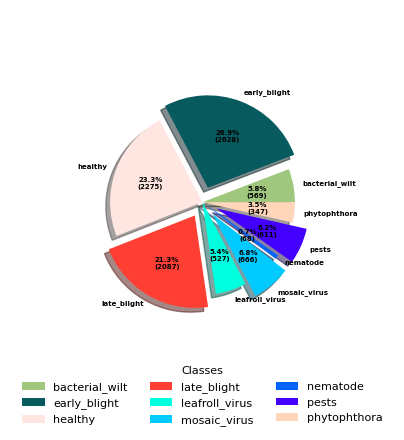

In [13]:
examples = samples
plt.figure(figsize=(5, 5))
def fmt(x, total):
    return '{:.1f}%\n({:.0f})'.format(x, total*x/100)

plt.pie(
    examples.values(), labels=examples.keys(), explode= [0. if i%2 == 0 else .1 for i in range(len(samples))],
    pctdistance=0.6, shadow=True, autopct=lambda x: fmt(x, sum(examples.values())),
    textprops={'color': 'black', 'fontsize': 5, 'weight': 'bold'},
    radius=.6, colors=PALETTES.kids[8:],
)
plt.legend(
    fontsize=8, loc="upper center",
    bbox_to_anchor=(0.5, 0.1),
    title="Classes", ncol=3, frameon=False, title_fontsize=8
)
plt.show()

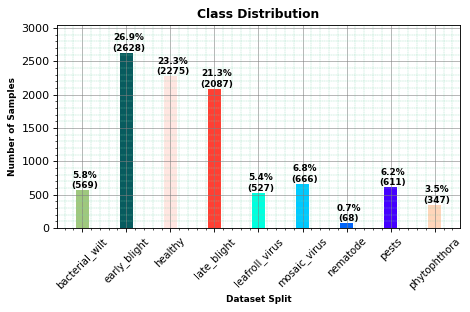

In [24]:
labels = list(examples.keys())
values = list(examples.values())

def fmt_bar(x, total):
    return '{:.1f}%\n({:.0f})'.format(x/total *100, x)

plt.figure(figsize=(6, 4), dpi=80 )
plt.ylim(0, max(values) * 1.16)
bars = plt.bar(labels, values, width=.3, color=PALETTES.kids[8:])
for index, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 1.5,
        height,
        fmt_bar(values[index], sum(values)),
        ha='center',
        va='bottom',
        fontsize=8,
        weight='bold'
    )

plt.xlabel('Dataset Split', fontsize=8, weight='bold')
plt.xticks(rotation=45, fontsize=9)
plt.ylabel('Number of Samples', fontsize=8, weight='bold')
plt.title('Class Distribution', fontsize=11, weight='bold')
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

Since the dataset is imbalanced, class weights are computed and incorporated into the loss function. This ensures that the model places greater emphasis on correctly classifying underrepresented classes by assigning higher penalties to errors made on minority classes.


### Class Weight Computation

The weight assigned to each class is computed as:

$$
w_i = \frac{N}{K \cdot n_i}
$$

Where:

- $w_i$ is the weight for class $i$
- $N = \sum_{i=1}^{K} n_i$ is the total number of samples
- $K$ is the total number of classes
- $n_i$ is the number of samples in class $i$

### Alternative Normalized Form

$$
w_i = \frac{\frac{1}{n_i}}{\sum_{j=1}^{K} \frac{1}{n_j}} \times K
$$

This gives higher weights to minority classes and lower weights to majority classes.  

In [14]:
def get_class_weights(values):
    values = torch.tensor(values, dtype=torch.float32)
    total = values.sum()
    weights = total / (len(values) * values)
    return weights
class_weights = get_class_weights(list(samples.values()))
class_weights

tensor([ 1.9094,  0.4134,  0.4776,  0.5206,  2.0616,  1.6313, 15.9771,  1.7781,
         3.1310])

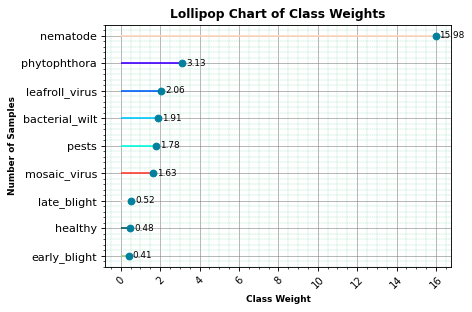

In [54]:
sorted_indices = torch.argsort(class_weights)
sorted_weights = class_weights[sorted_indices]
sorted_names = [list(samples.keys())[i] for i in sorted_indices]

plt.figure(figsize=(6, 4), dpi=80)
plt.hlines(y=sorted_names, xmin=0, xmax=sorted_weights.numpy(), color=PALETTES.kids[8:])
plt.plot(sorted_weights.numpy(), sorted_names, 'o', color=PALETTES.kids[3])

for x, y in zip(sorted_weights, sorted_names):
    plt.text(x + 0.2, y, f"{x:.2f}", va='center', fontsize=8)


plt.xlabel("Class Weight", fontsize=8, weight='bold')
plt.xticks(rotation=45, fontsize=9)
plt.ylabel('Number of Samples', fontsize=8, weight='bold')
plt.title("Lollipop Chart of Class Weights", fontsize=11, weight='bold')
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

### Channel Means and Standard Deviations

In this step, the **mean** and **standard deviation** for each image channel are computed across the dataset to support image normalization.

Normalization ensures that input data is consistently scaled, which:
- Stabilizes gradient updates  
- Accelerates training convergence  
- Improves overall model performance  

Using dataset-specific statistics allows the normalization process to accurately reflect the underlying data distribution, leading to better generalization.

The computed values are then used to normalize the images prior to training, ensuring that the model receives standardized inputs throughout the learning process.

In [55]:
train_data = datasets.ImageFolder(
    root=target_root,
    transform= transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor()
      ])
    )
means = torch.zeros(3)
stds = torch.zeros(3)

for img, label in train_data:
  means += torch.mean(img, dim = (1,2))
  stds += torch.std(img, dim = (1,2))

means /= len(train_data)
stds /= len(train_data)

print(f'Calculated means: {means}')
print(f'Calculated stds: {stds}')


Calculated means: tensor([0.4292, 0.4757, 0.3814])
Calculated stds: tensor([0.1814, 0.1702, 0.2253])


### Image Normalization, Resizing, and Augmentation

Based on the computed channel-wise means and standard deviations, an average value is used to normalize all images. This ensures consistent input scaling, which improves training stability and convergence.

All images are resized to **96x96 pixels** to maintain uniform input dimensions and are converted to **grayscale** to reduce computational complexity while preserving essential structural features.

In addition, data augmentation techniques are applied to the training set, including:
- Random rotations  
- Horizontal flipping  
- Slight cropping  

These transformations introduce variability into the dataset, helping to:
- Reduce overfitting  
- Improve model robustness  
- Enhance generalization to unseen data  

The transformations for each dataset split are as follows:

```python
"train": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(96, padding=2),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
]),
"valid": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
]),
"test": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
])
```


These transformations ensure that the data is standardized, and the training set benefits from random augmentations to make the model more robust.

In [56]:
mean = means.mean().item()
std = stds.mean().item()

image_transforms = {
    "train": transforms.Compose([
       transforms.Resize([96,96]),
       transforms.RandomRotation(5),
       transforms.RandomHorizontalFlip(.5),
       transforms.RandomCrop(96, padding=2),
       transforms.ToTensor(),
       transforms.Grayscale(
         num_output_channels =1
       ),
       transforms.Normalize(mean=[mean], std=[std], inplace=False)
    ]),
    "valid": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels=1
       ),
        transforms.Normalize(mean=[mean], std=[std], inplace=False)
    ]),
    "test": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels =1
       ),
        transforms.Normalize(mean=[mean], std=[std], inplace=False)
    ])
}

In the following code cell, datasets are created using the PyTorch ImageFolder class, which automatically associates images with their respective class labels based on the directory structure. This simplifies data handling and enables efficient preparation of both the training and testing sets for model development.


In [57]:
dataset = datasets.ImageFolder(target_root, transform = image_transforms['train'])
class_names = dataset.classes
class_names

['bacterial_wilt',
 'early_blight',
 'healthy',
 'late_blight',
 'leafroll_virus',
 'mosaic_virus',
 'nematode',
 'pests',
 'phytophthora']

## Data Splitting

The dataset is divided into three subsets: **training**, **validation**, and **testing**.

- **20%** of the data is reserved as the **test set**  
- The remaining **80%** is further split into:
  - **80% for training**
  - **20% for validation**

This results in an approximate distribution of:
- **64% Training**
- **16% Validation**
- **20% Testing**

The **training set** is used to learn model parameters.  
The **validation set** is used to monitor performance during training and guide hyperparameter tuning.  
The **test set** is kept completely separate and is used only for the final, unbiased evaluation of the model.


In [58]:
VALID_RATIO = 0.2
TEST_RATIO = 0.2

# Split into train + test
n_test_examples = int(len(dataset) * TEST_RATIO)
n_train_examples = len(dataset) - n_test_examples

train_data, test_data = data.random_split(dataset,
                                          [n_train_examples, n_test_examples])
n_valid_examples = int(len(train_data) * VALID_RATIO)
n_train_examples = len(train_data) - n_valid_examples
train_data, valid_data = data.random_split(train_data,
                                           [n_train_examples, n_valid_examples])


After splitting the dataset, all subsets initially inherit the training transformation pipeline, including augmentation. To ensure fair and consistent evaluation, separate dataset instances are created for the **validation** and **test** sets, where the transformations are overridden to include only deterministic preprocessing steps such as **resizing** and **normalization**, excluding any augmentation.

This ensures that:
- The model is evaluated on unaltered, realistic data  
- Performance metrics are reliable and not influenced by random transformations  
- Validation and test results accurately reflect the model’s generalization ability  


In [59]:
valid_data = copy.deepcopy(valid_data)
test_data = copy.deepcopy(test_data)

valid_data.dataset.transform = image_transforms['valid']
test_data.dataset.transform = image_transforms['test']

In the following code cell we are going to use the pie chat to visualize the examples that we have in each subset.

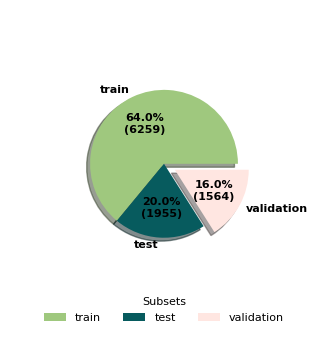

In [61]:
plt.figure(figsize=(4, 4))
plt.pie(
    [len(train_data), len(test_data), len(valid_data)], explode= [.0, .0, .1],
    labels=['train', 'test', 'validation'],
    pctdistance=0.6, shadow=True, autopct=lambda x: fmt(x, sum([len(train_data), len(test_data), len(valid_data)])),
    textprops={'color': 'black', 'fontsize': 8, 'weight': 'bold'},
    radius=.6, colors=PALETTES.kids[8:]
)
plt.legend(
    fontsize=8,  loc="upper center",
    bbox_to_anchor=(0.5, 0.1),
    title="Subsets", ncol=3, frameon=False, title_fontsize=8
)
plt.show()

In the following code cell, a bar plot for the distribution of samples in each subset.

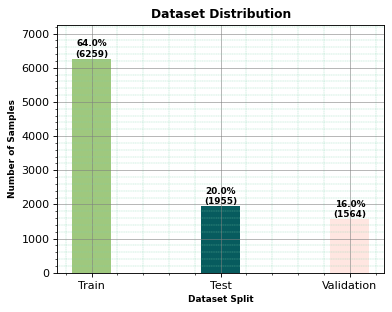

In [62]:
labels = ['Train', 'Test', 'Validation']
values = [len(train_data), len(test_data), len(valid_data)]

def fmt_bar(x, total):
    return '{:.1f}%\n({:.0f})'.format(x/total *100, x)

plt.figure(figsize=(5, 4), dpi=80 )
plt.ylim(0, max(values) * 1.16)
bars = plt.bar(labels, values, width=.3, color=PALETTES.kids[8:])
for index, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        fmt_bar(values[index], sum(values)),
        ha='center',
        va='bottom',
        fontsize=8,
        weight='bold'
    )

plt.xlabel('Dataset Split', fontsize=8, weight='bold')
plt.ylabel('Number of Samples', fontsize=8, weight='bold')
plt.title('Dataset Distribution', fontsize=11, weight='bold')
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

## Data Loading

Data iterators (**DataLoaders**) are created to efficiently feed the dataset into the model during training and evaluation, with a **batch size of 64**.

Using mini-batches offers several advantages:
- Allows more frequent weight updates compared to full-batch training  
- Provides more stable gradient estimates than very small batch sizes  
- Enables efficient parallel computation on modern hardware (e.g., GPUs)  

A batch size of **64** provides a practical balance between:
- **Computational efficiency**  
- **Memory usage**  
- **Training stability**  

Additionally, moderate batch sizes introduce a small amount of noise in gradient updates, which can:
- Help prevent overfitting  
- Encourage better generalization  
- Support convergence to more optimal solutions  

In [63]:
BATCH_SIZE = 64
train_iterator = data.DataLoader(
    train_data, shuffle=True, batch_size= BATCH_SIZE
)
valid_iterator = data.DataLoader(
    valid_data, batch_size= BATCH_SIZE
)
test_iterator = data.DataLoader(
    test_data,  batch_size= BATCH_SIZE
)

### Visualizing Images

In this section, sample images from the dataset are visualized alongside their corresponding labels to provide an intuitive understanding of the data. This step is an important part of exploratory data analysis, as it allows for inspection of image quality, class characteristics, and potential issues such as noise or mislabeling. Visualizing the data also helps confirm that preprocessing steps have been applied correctly and ensures that the classes are distinguishable, which is essential for effective model training and reliable performance.

In [64]:
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min = image_min, max = image_max)
  image.add_(-image_min).div_(image_max - image_min + 1e-5)
  return image

Next we are going to define the `plot_images` function which is responsible for plotting images.

In [67]:
def plot_images(images, labels, normalize = True):
  n_images = len(images)
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (10, 10))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image = images[i]
    if normalize:
        image = normalize_image(image)

    ax.imshow(image.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    ax.set_title(class_names[labels[i]], fontsize=10, color='g' if labels[i] == 2 else 'r')
    ax.axis('off')


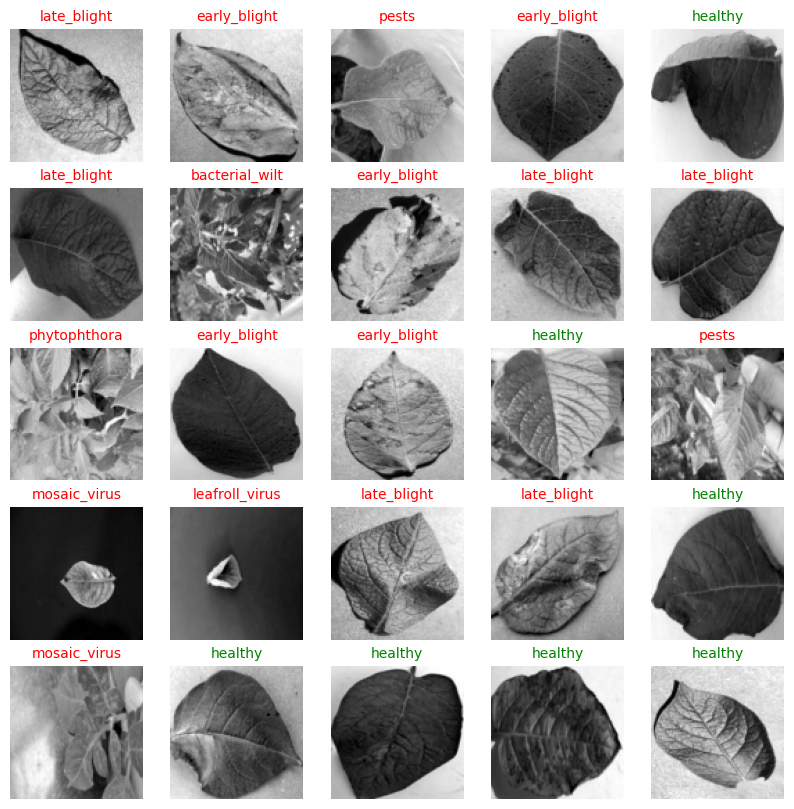

In [68]:
N_IMAGES = 25
labeled_data = next(iter(test_iterator))

images, labels = labeled_data[0][:N_IMAGES], labeled_data[1][:N_IMAGES]
plot_images(images, labels)

## LeNet Model

In the following code cell, a **LeNet** model is defined as a convolutional neural network (CNN) for the potato leaf disease classification task.

LeNet leverages **convolutional** and **pooling** layers to capture spatial features such as textures, edges, and patterns in leaf images.

Key characteristics of LeNet:
- Extracts hierarchical spatial features from images  
- Reduces dimensionality through pooling operations  
- Maintains a lightweight architecture suitable for efficient training  

As a simple yet effective CNN, LeNet serves as a strong baseline for this task, demonstrating the advantages of spatial feature learning in image classification while maintaining low computational complexity.

In [69]:
class LeNet(nn.Module):
    def __init__(self, output_dim, input_size=96):
        super(LeNet, self).__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            dummy = self.convs(dummy)
            self.flatten_dim = dummy.view(1, -1).shape[1]
        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.convs(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In the following code cell, we will create an instance of the LeNet model, initializing the convolutional network with the defined architecture and preparing it for training and evaluation on the potato leaf disease dataset.

In [70]:
OUTPUT_DIM = 1 if len(class_names) == 2 else len(class_names)
INPUT_DIM = 96
lenet = LeNet(OUTPUT_DIM, input_size = INPUT_DIM).to(device)
lenet

LeNet(
  (convs): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=7056, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=9, bias=True)
  )
)

## Model Complexity Analysis

In this section, the computational complexity of the model is analyzed by estimating the number of **parameters** and **floating point operations (FLOPs)**. These metrics quantify the amount of computation required during a forward pass.

FLOPs are commonly approximated as:
- **2 x MACs (Multiply-Accumulate Operations)**  
  - One multiplication  
  - One addition  

The computation of FLOPs varies depending on the layer type:

### Fully Connected Layers
For fully connected (dense) layers, FLOPs are determined by:
- The number of input units  
- The number of output units  

This reflects the total number of connections between neurons.

### Convolutional Layers
For convolutional layers, FLOPs depend on:
- Kernel size (height x width)  
- Number of input channels  
- Number of output channels  
- Spatial dimensions of the output feature map  

These factors collectively determine how many operations are required to produce each feature map.


### Importance of Complexity Analysis

Evaluating model complexity is important for:
- Comparing computational efficiency  
- Estimating inference time  
- Assessing suitability for deployment in **resource-constrained environments**  

This is particularly relevant for lightweight architectures such as **LeNet**, where efficiency is a key advantage.


### Limitations of FLOPs

While FLOPs provide a useful estimate of computational cost, they have limitations:
- Do not account for memory access overhead  
- Ignore hardware-specific optimizations (e.g., GPU parallelism)  
- May not fully reflect real-world runtime performance  

As a result, models with similar FLOPs can still exhibit different practical performance depending on the execution environment.

In [71]:
def count_params(model):
  total_params = sum([p.numel() for p in model.parameters()])
  trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return f'{total_params:,}', f'{trainable_params:,}', f'{total_params - trainable_params:,}'

def compute_flops(model):
    with torch.cuda.device(0):
        macs, params = get_model_complexity_info(
            model,
            (1, 96, 96),
            as_strings=True,
            print_per_layer_stat=False,
            verbose=False
        )
    return macs, params

Then we will visualize the model parameters using a table.

In [72]:
tabulate_data(
    ["NAME", "TOTAL PARAMETERS", "TRAINABLE PARAMETERS", "NON-TRAINABLE PARAMETERS", "FLOPs (MACs)", "SHORTENED PARAMS",],
    [
      ['lenet', *count_params(lenet), *compute_flops(lenet)],
    ],
    "MODELS' PARAMETERS"
)

MODELS' PARAMETERS
+-------+------------------+----------------------+--------------------------+--------------+------------------+
| NAME  | TOTAL PARAMETERS | TRAINABLE PARAMETERS | NON-TRAINABLE PARAMETERS | FLOPs (MACs) | SHORTENED PARAMS |
+-------+------------------+----------------------+--------------------------+--------------+------------------+
| lenet |          914,709 |              914,709 |                        0 |    6.81 MMac |         914.71 k |
+-------+------------------+----------------------+--------------------------+--------------+------------------+


## Criterion and Optimizer

Next, the **optimizer** and **loss function** are defined for training the model.

The **Adam optimizer** is used due to its ability to adaptively adjust learning rates for each parameter. This results in:
- Faster convergence  
- Efficient handling of sparse gradients  
- Improved overall training performance  

For the loss function, **CrossEntropyLoss** is employed, as it is well-suited for **multiclass classification** problems such as potato leaf disease classification.

In addition, **class weights** are incorporated into the loss function to address class imbalance. This ensures that:
- Errors on minority classes are penalized more heavily  
- The model does not become biased toward majority classes  
- Learning remains balanced across all classes  

CrossEntropyLoss works by measuring the difference between predicted class probabilities and the true labels, enabling effective optimization of the model during training.


In [77]:
optimizers = {
    'lenet': torch.optim.Adam(lenet.parameters()),
}
criterions = {
    'lenet': nn.CrossEntropyLoss(weight=class_weights ).to(device),
}

In the following code cell, the categorical_accuracy function is defined to compute the model's accuracy by comparing predicted class labels with the true labels. This metric provides a straightforward measure of how well the model correctly classifies samples, making it useful for evaluating performance during both training and validation phases.

In [78]:
def categorical_accuracy(y_pred, y):
  top_pred = y_pred.argmax(1, keepdim=True)
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float()/ y.shape[0]
  return acc

### Train and Evaluate Functions

In the following code cell we are going to define the `train` and `evaluate` fuctions.

In [79]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.train()
  for (x, y) in iterator:
    # features and labels to the device
    x = x.to(device)
    y = y.to(device).long()
    # Zero the gradients
    optimizer.zero_grad()
    y_pred = model(x)
    # Calculate the loss and accuracy
    y_pred = y_pred.squeeze()

    loss = criterion(y_pred, y)
    acc = categorical_accuracy(y_pred, y)
    # Backward propagate
    loss.backward()
    # Update the weights
    optimizer.step()
    epoch_loss +=loss.item()
    epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

def evaluate(model, iterator, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.eval()
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y = y.to(device).long()
      y_pred = model(x)
      y_pred = y_pred.squeeze()
      loss = criterion(y_pred, y)
      acc = categorical_accuracy(y_pred, y)

      epoch_loss += loss.item()
      epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

Next we are going to create a `History` wrapper class so that we can keep in track of the model's metrics during training.

In [80]:
class History:
  def __init__(self):
    self.train_losses = list()
    self.train_acc = list()
    self.epoch_train_time = list()
    self.val_losses = list()
    self.val_acc = list()

  def add(self, train_loss:float, train_acc:float, val_loss:float, val_acc:float, elt:float):
    self.train_losses.append(train_loss)
    self.val_losses.append(val_loss)
    self.train_acc.append(train_acc)
    self.val_acc.append(val_acc)
    self.epoch_train_time.append(elt)

Next we are going to define the `train_model` function which is responsible for training the model and return model training history.

In [81]:
EPOCHS = 30

def train_model(model, model_name, train_iterator, optimizer, criterion, device, valid_iterator, epochs):
  best_valid_loss = float('inf')
  column_names = ["Set", "Loss", "Accuracy", "ETA (time)"]
  last_saved_epoch = 1

  history = History()
  training_start = time.time()
  for epoch in range(epochs):
    start = time.time()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    save_status = "(not saving)"
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      save_status = "(saving)"
      last_saved_epoch = epoch + 1
      torch.save(model.state_dict(), model_name)

    end = time.time()
    history.add(train_loss, train_acc, valid_loss, valid_acc, end-start)

    data_rows = [
        ["Train", f'{train_loss:.3f}', f'{train_acc * 100:.2f}%', hms_string(end-start)],
        ["Validation", f'{valid_loss:.3f}', f'{valid_acc * 100:.2f}%', ""]
    ]
    title = f"{model_name.replace('.pt', '')}: EPOCH {epoch+1:02}/{epochs}: {save_status}"
    print(title)
    for row in data_rows:
        print(" | ".join(row), ' |')
    print()

  training_end = time.time()
  return history, training_end - training_start, last_saved_epoch

In [82]:
lenet_history, lenet_training_end, lenet_last_saved_epoch = train_model(
     lenet, 'lenet.pt', train_iterator, optimizers['lenet'], criterions['lenet'], device, valid_iterator, epochs=EPOCHS
)

lenet: EPOCH 01/30: (saving)
Train | 1.534 | 40.47% | 0:00:38.92  |
Validation | 1.270 | 49.02% |   |

lenet: EPOCH 02/30: (saving)
Train | 1.151 | 53.47% | 0:00:34.88  |
Validation | 1.103 | 57.77% |   |

lenet: EPOCH 03/30: (not saving)
Train | 1.017 | 58.99% | 0:00:35.71  |
Validation | 1.161 | 62.30% |   |

lenet: EPOCH 04/30: (saving)
Train | 0.966 | 62.12% | 0:00:40.30  |
Validation | 1.020 | 58.68% |   |

lenet: EPOCH 05/30: (not saving)
Train | 0.853 | 64.35% | 0:00:43.81  |
Validation | 1.043 | 61.25% |   |

lenet: EPOCH 06/30: (not saving)
Train | 0.829 | 66.82% | 0:00:42.47  |
Validation | 1.042 | 64.32% |   |

lenet: EPOCH 07/30: (not saving)
Train | 0.795 | 68.52% | 0:00:42.82  |
Validation | 1.021 | 67.06% |   |

lenet: EPOCH 08/30: (saving)
Train | 0.717 | 70.72% | 0:00:43.66  |
Validation | 0.942 | 66.54% |   |

lenet: EPOCH 09/30: (saving)
Train | 0.668 | 72.19% | 0:00:43.30  |
Validation | 0.902 | 68.29% |   |

lenet: EPOCH 10/30: (not saving)
Train | 0.610 | 73.32% |

### Model Training Time

In the following code cell, a tabulated summary of each model’s total training time and the epoch corresponding to the final saved checkpoint is presented to assess training efficiency and convergence behavior. Additionally, the number of trainable parameters and the estimated FLOPs are reported to quantify computational complexity, enabling a comprehensive comparison between models in terms of both performance and resource requirements.

In [83]:
rows = [
    ['lenet', f'{EPOCHS}', f'{hms_string(lenet_training_end)}', f'{lenet_last_saved_epoch}', *compute_flops(lenet)],
]
tabulate_data(['MODEL','TOTAL EPOCHS', 'TOTAL TRAINING TIME',
               'LAST SAVED EPOCH', "FLOPs (MACs)", "PARAMS"], rows, "TOTAL TRAINING TIME")

TOTAL TRAINING TIME
+-------+--------------+---------------------+------------------+--------------+----------+
| MODEL | TOTAL EPOCHS | TOTAL TRAINING TIME | LAST SAVED EPOCH | FLOPs (MACs) |   PARAMS |
+-------+--------------+---------------------+------------------+--------------+----------+
| lenet |           30 |          0:21:18.08 |                9 |    6.81 MMac | 914.71 k |
+-------+--------------+---------------------+------------------+--------------+----------+


In the following code cell, the model's training time per epoch is visualized to show how computational cost varies across epochs. This helps assess training efficiency and can reveal potential bottlenecks or irregularities during the learning process.

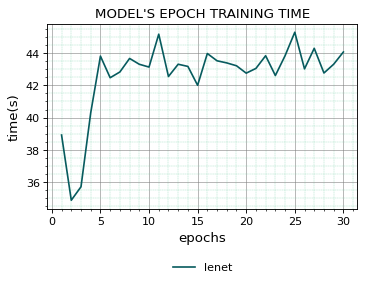

In [84]:
epochs = np.arange(1, EPOCHS + 1)
plt.figure(figsize=(5, 3), dpi=80)
plt.plot(epochs, lenet_history.epoch_train_time, label="lenet", color=PALETTES.kids[9])
plt.title("MODEL'S EPOCH TRAINING TIME", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("time(s)", fontsize=12)

plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.legend(loc="lower center",
    ncol=3, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.show()

### Validation and Training Accuracies

In the following code cell, the model's training and validation accuracies are visualized across epochs using line graphs. This enables tracking of learning progress over time, helping to assess performance improvements and identify potential issues such as overfitting or underfitting during training.

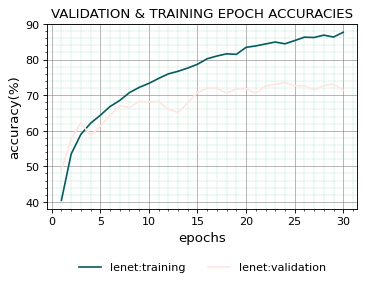

In [85]:
plt.figure(figsize=(5, 3), dpi=80)
plt.plot(epochs, [i * 100 for i in lenet_history.train_acc], label="lenet:training", color=PALETTES.kids[9])
plt.plot(epochs, [i * 100 for i in lenet_history.val_acc], label="lenet:validation", color=PALETTES.kids[10])

plt.title("VALIDATION & TRAINING EPOCH ACCURACIES", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("accuracy(%)", fontsize=12)
plt.legend(loc="lower center",
    ncol=2, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.show()

### Validation and Training Losses

In the following code cell, the model's training and validation losses are visualized across epochs using line graphs. This allows monitoring of the learning process, helping to assess convergence and detect issues such as overfitting or underfitting during training.

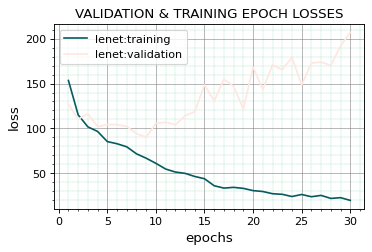

In [86]:
plt.figure(figsize=(5, 3), dpi=80)

plt.plot(epochs, [i * 100 for i in lenet_history.train_losses], label="lenet:training", color=PALETTES.kids[9])
plt.plot(epochs, [i * 100 for i in lenet_history.val_losses], label="lenet:validation", color=PALETTES.kids[10])

plt.title("VALIDATION & TRAINING EPOCH LOSSES", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("loss", fontsize=12)
plt.legend()

plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.show()

### Best Model Evaluation

In the following code cell, a function is defined to evaluate the best saved model from training by computing its loss and accuracy on the test dataset. This provides a reliable measure of the model's generalization performance on unseen data and enables an objective assessment of its effectiveness.


In [87]:
def evaluate_best_model(model, model_name, test_iterator, criterion, device):
  model.load_state_dict(torch.load(model_name, weights_only=True))
  test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
  return f'{test_loss:.2f}', f'{test_acc * 100:.2f}'


tabulate_data(
    ["NAME", "LOSS", "ACCURACY (%)"],
    [
        ['lenet', *evaluate_best_model(lenet, 'lenet.pt', test_iterator, criterions['lenet'], device)],
    ],
    "BEST MODEL'S LOSS AND ACCURACY"
)

BEST MODEL'S LOSS AND ACCURACY
+-------+------+--------------+
| NAME  | LOSS | ACCURACY (%) |
+-------+------+--------------+
| lenet | 0.97 |        68.24 |
+-------+------+--------------+


### Model Evaluation Metrics

In this section, the best-performing model is evaluated using key metrics to assess its classification performance. For this multiclass task, a confusion matrix is used to visualize how well the model predicts each class, while a classification report provides detailed metrics including precision, recall, F1-score, and support for each class. The process begins by obtaining predictions from the dataset, which are then used to compute these evaluation measures and provide a comprehensive understanding of the model's strengths and weaknesses.

In [88]:
def get_predictions(model, iterator, device):
  model.eval()
  images = []
  labels = []
  probs = []
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y_pred = model(x)
      y_prob = F.softmax(y_pred, dim = -1)
      top_pred = y_prob.argmax(1, keepdim = True)
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob.cpu())
  images = torch.cat(images, dim = 0)
  labels = torch.cat(labels, dim = 0)
  probs = torch.cat(probs, dim = 0)
  return images, labels, probs

lenet_test_images, lenet_test_labels, lenet_probs = get_predictions(lenet, test_iterator, device)

Next we are going to convert our predictions from probabilities to real labels.

In [89]:
lenet_preds = torch.argmax(lenet_probs, 1).numpy().astype(np.int32)
lenet_test_labels = lenet_test_labels.numpy()

### Plotting Predictions

In this section, the model's predictions are visualized on sample images from the dataset to provide a qualitative assessment of its performance. This helps illustrate how well the model distinguishes between classes and offers intuitive insight into its classification behavior on real examples.

In [90]:
def get_predictions_labels(test_images, preds, test_labels):
    test_images_labels = list(zip(test_images, preds, test_labels))
    random.shuffle(test_images_labels)
    y_true = []
    y_pred = []
    images = []

    for img, pred, label in test_images_labels[:24]:
      y_true.append(label)
      y_pred.append(pred)
      images.append(img)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return images, y_true, y_pred
lenet_images, lenet_y_true, lenet_y_pred = get_predictions_labels(lenet_test_images, lenet_preds, lenet_test_labels)

Next we are going to define the function that will plot the predictions for us.

In [91]:
def plot_predictions_images(images_and_classes,
                            labels_true, labels_pred,
                            cols=5):
    rows = 3
    fig = plt.figure()
    fig.set_size_inches(cols * 2, rows * 2)
    for i, (image, label_true, label_pred) in enumerate(zip(images_and_classes, labels_true.astype("int32"), labels_pred)):
        plt.subplot(rows, cols, i + 1)
        plt.axis('off')
        image = normalize_image(image)
        plt.imshow(image.permute(1, 2, 0).cpu().numpy(), cmap="gray")
        plt.title(class_names[label_pred], color ='g' if label_true == label_pred else 'r', fontsize=10 )

Next, we will plot the predictions made by the LeNet model, allowing us to visually assess how accurately it classifies sample images. L

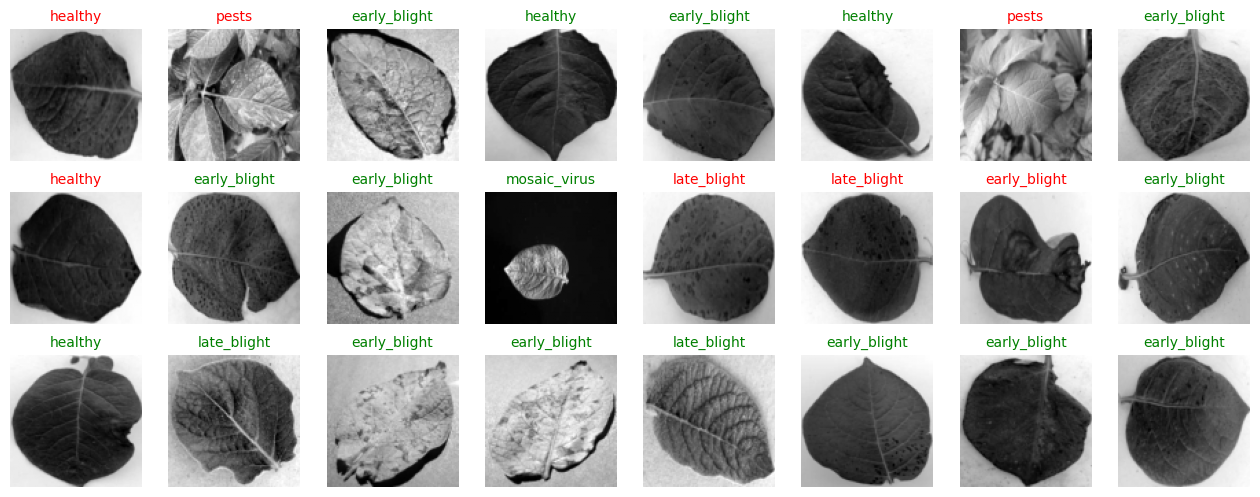

In [92]:
plot_predictions_images(lenet_images[:24], lenet_y_true[:24], lenet_y_pred[:24], cols=8)

The figure shows that the LeNet model from a sample of 24 was able to predict correctly all the images as the titles of the images are all "green".


### Confusion Matrix

In the following code cell, the confusion matrix is visualized using the test dataset to provide a detailed view of the model's classification performance. It shows how well each class is predicted and highlights any misclassifications, helping to identify patterns of errors across the different classes.

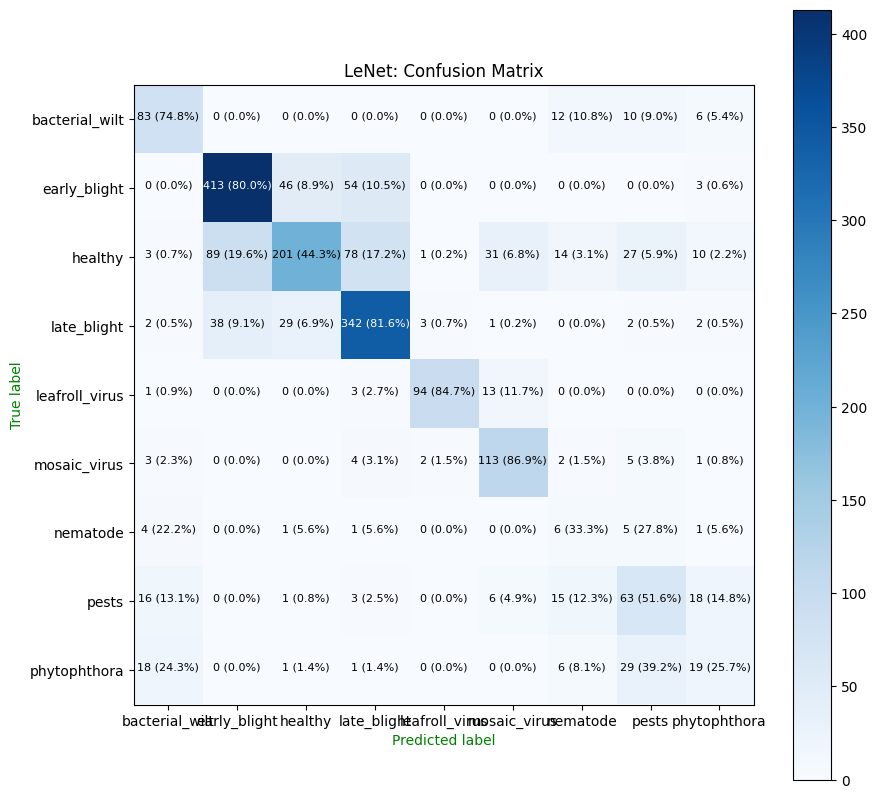

In [102]:
plot_complicated_confusion_matrix(lenet_test_labels, lenet_preds, class_names,
                                  fontsize=8, figsize=(10, 10), title="LeNet: Confusion Matrix")

### Classification Report

In the following code cell, the classification report is generated for the best model using the test dataset. This report provides detailed metrics—including precision, recall, F1-score, and support for each class—offering a comprehensive evaluation of the model's performance across all categories.

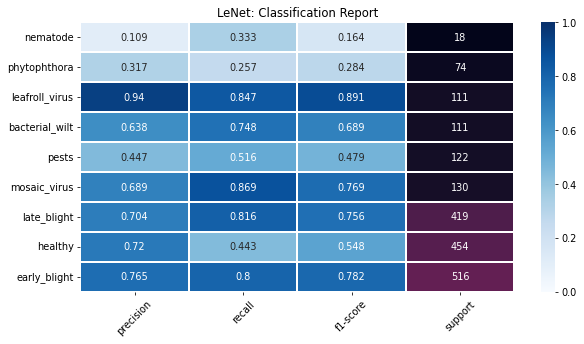

In [94]:
fig, ax = visualization.plot_classification_report(lenet_test_labels, lenet_preds,
                    title='LeNet: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = class_names
)


### Misclassified Potato Leaf Images

In this section, we will plot the misclassified potato leaf images, if any exist, to visually analyze the model's errors. This helps identify which classes are more challenging for the model to distinguish and provides insight into potential areas for improvement.


In [95]:
lenet_corrects = torch.eq(torch.from_numpy(lenet_test_labels), torch.from_numpy(lenet_preds))

In [96]:
def get_incorrect_examples(images, labels, probabilities, corrects):
  incorrect_examples = []
  for image, label, prob, correct in zip(images, labels, probabilities, corrects):
    if not correct:
      incorrect_examples.append((image, label, prob))
  return incorrect_examples
lenet_incorrect_examples = get_incorrect_examples(lenet_test_images, lenet_test_labels, lenet_probs, lenet_corrects)

In [97]:
def plot_most_incorrect(incorrect, classes, n_images, normalize = True):
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (6, 4))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image, true_label, probs = incorrect[i]
    image = image.permute(1, 2, 0)
    true_class = classes[true_label]
    incorrect_class = classes[0 if true_label == 1 else 1]
    if normalize:
      image = normalize_image(image)
    ax.imshow(image.cpu().numpy(), cmap='gray')
    ax.set_title(f'real: {true_class}\n' \
                  f'predicted: {incorrect_class}', fontsize=8)
    ax.axis('off')
  fig.subplots_adjust(hspace=0.4)

In the following code cell, we will plot the most mispredicted potato leaf images by the model, highlighting the samples where the model is most confident yet incorrect to better understand its failure cases.

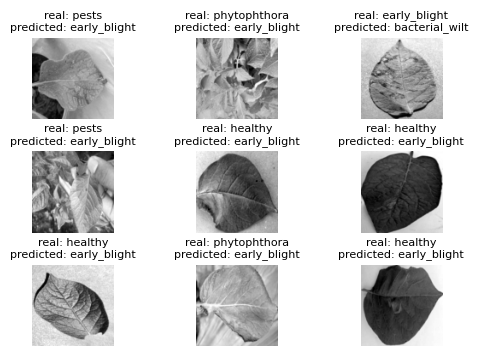

In [98]:
N_IMAGES = 12
try:
    plot_most_incorrect(lenet_incorrect_examples, class_names, N_IMAGES)
except:
    print("No incorrectly Predicted Images")

### Grad-CAM for Qualitative Misclassification Analysis

**Gradient-weighted Class Activation Mapping (Grad-CAM)** is an explainability technique used to visualize which regions of an input image most influenced a convolutional neural network’s prediction. It works by computing gradients of the target class with respect to feature maps to produce a localization heatmap.

In this notebook, Grad-CAM is applied **without retraining the model** as a qualitative tool to interpret model behavior, particularly for **misclassified potato leaf images**. This allows us to assess whether the model focuses on meaningful disease-related regions or irrelevant background patterns.

Grad-CAM is suitable for the **LeNet** model because it contains convolutional layers that preserve spatial information required for localization. In contrast, it is not applicable to models without convolutional feature maps.

For this analysis:
- Heatmaps are generated from the **last convolutional layer**, where higher-level, discriminative features are captured  
- The heatmaps are **overlaid on the original images** to visualize model attention  
- Misclassified samples are specifically analyzed to understand failure cases  

This approach enhances evaluation by complementing quantitative metrics with interpretability, providing deeper insight into model reliability and the underlying causes of misclassification.


In [99]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_hook = target_layer.register_forward_hook(self.save_activations)
        self.bwd_hook = target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, inp, out):
        self.activations = out.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        grads = self.gradients[0]         # [C, H, W]
        acts = self.activations[0]        # [C, H, W]

        weights = grads.mean(dim=(1, 2))  # [C]
        cam = torch.zeros(acts.shape[1:], device=acts.device)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

In the following code cell, we create a Grad-CAM object for the `LeNet` model to enable visualization of the regions influencing its predictions.

In [100]:
gradcam = GradCAM(lenet, lenet.convs[3])

### Grad-CAM Visualization of Correctly Classified Samples

In this section, Grad-CAM is applied to **incorrectly classified** potato leaf images from the test set to provide qualitative insight into the **LeNet model's decision-making process**.

For each image, three visualizations are presented:
- The **original image** with its true label  
- The **Grad-CAM heatmap** highlighting the most influential regions for the prediction  
- An **overlay** combining the original image and the heatmap to show where the model focused  

This analysis helps verify whether the model is attending to **meaningful regions of the leaf**, such as disease spots, discoloration, or texture patterns, rather than irrelevant background features.

By examining these attention patterns, Grad-CAM provides interpretability that complements quantitative metrics, offering deeper insight into model reliability and confirming that predictions are based on relevant visual cues.

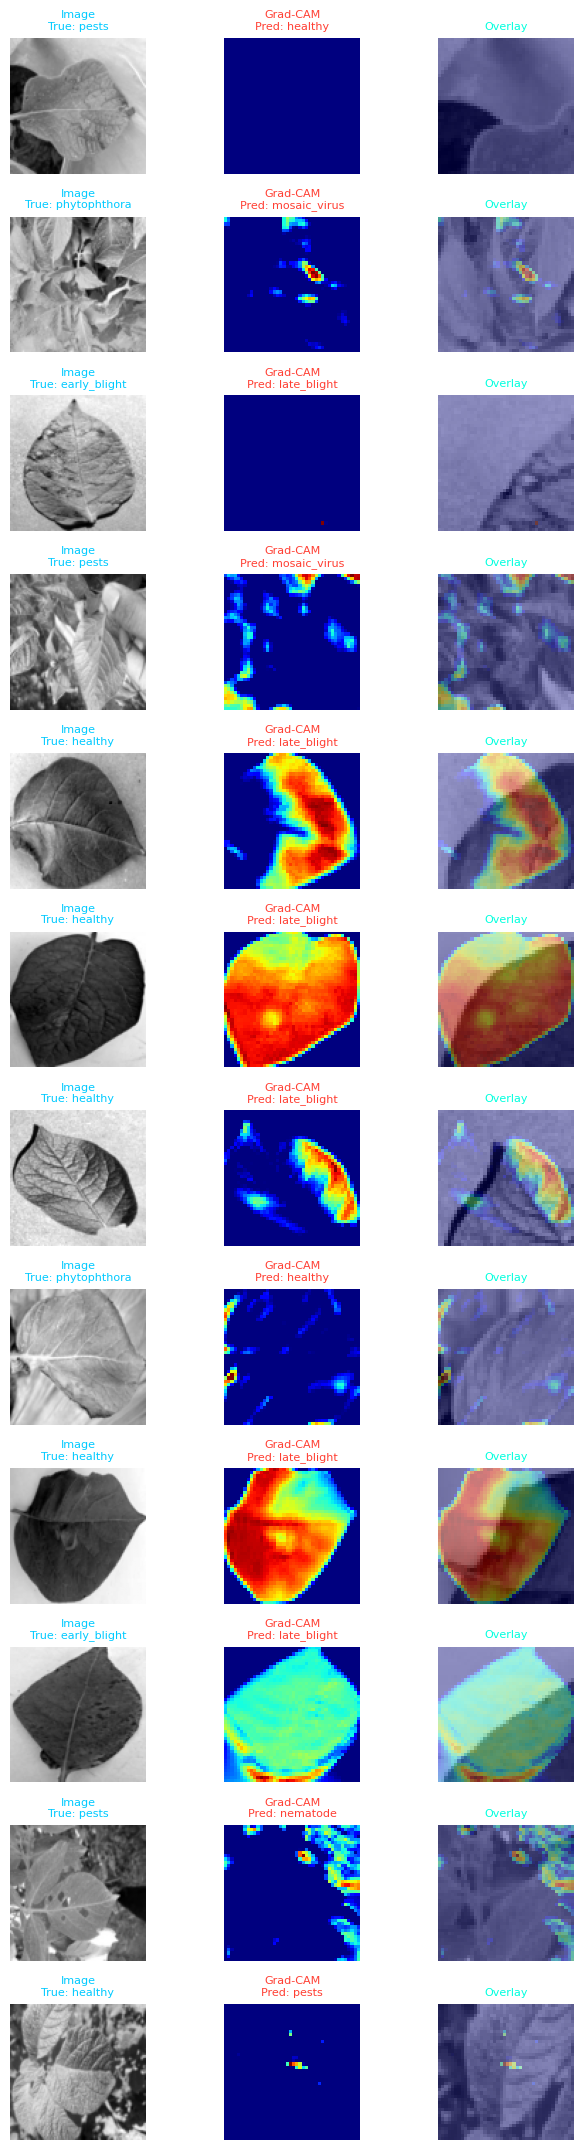

In [106]:
gradcam = GradCAM(lenet, lenet.convs[3])
samples = lenet_incorrect_examples[:N_IMAGES]

plt.figure(figsize=(7, 1.8 * N_IMAGES))
for i, (image, true_label, prob) in enumerate(samples):
    x = image.unsqueeze(0).to(device)
    cam, pred_class = gradcam.generate(x)
    img = image.squeeze().cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.subplot(N_IMAGES, 3, i * 3 + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Image\nTrue: {class_names[true_label]}", fontsize=8, color=PALETTES.kids[13])
    plt.axis('off')

    plt.subplot(N_IMAGES, 3, i * 3 + 2)
    plt.imshow(cam, cmap='jet')
    plt.title(f"Grad-CAM\nPred: {class_names[pred_class]}", fontsize=8, color=PALETTES.kids[11])
    plt.axis('off')

    plt.subplot(N_IMAGES, 3, i * 3 + 3)
    plt.imshow(img, cmap='gray')
    plt.imshow(cam, cmap='jet', alpha=0.4)
    plt.title("Overlay", color=PALETTES.kids[12], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()